In [1]:
import polars as pl
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from linearmodels.iv import compare
from linearmodels.panel.results import compare
import statsmodels.api as sm
from statsmodels.api import qqplot
from linearmodels.panel import PanelOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats as scipy_stats

import pyreadstat as prs
import pygwalker as pyg

import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

import json

from tqdm.notebook import tqdm
from itables import init_notebook_mode
# init_notebook_mode()

In [174]:
panel = pd.read_parquet('../data/wages_working_data3.parquet')
#panel['period_relevance'] = panel['period_relevance'] - 1
panel = panel[panel['year'].isin([
    # 2016,
    # 2017, 
    # 2018,
    2019, 
    2020, 
    #2022
])]
panel

,idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,...,is_married,period_relevance,is_town,is_female,has_disability_common,male_retiered,female_retiered,is_retired,has_disability_period,has_disability_common_period
0,60.0,2019.0,0,0,0.0,0.0,18000.0,0.0,18000.0,0.0,...,1,-1,1,1,0,0,0,0,0,0
1,60.0,2020.0,0,0,0.0,0.0,30000.0,0.0,30000.0,0.0,...,1,0,1,1,0,0,0,0,1,1
5,125.0,2019.0,1,1,15000.0,0.0,35000.0,0.0,20000.0,0.0,...,1,-1,0,1,0,0,0,0,0,0
6,125.0,2020.0,1,1,16000.0,0.0,45500.0,0.0,29500.0,0.0,...,1,0,0,1,0,0,0,0,1,1
11,126.0,2019.0,0,0,0.0,0.0,20000.0,0.0,20000.0,0.0,...,1,-1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14913,59275.0,2020.0,0,0,0.0,0.0,27000.0,0.0,27000.0,0.0,...,0,0,1,0,0,0,0,0,1,1
14915,59277.0,2019.0,0,0,0.0,0.0,40000.0,0.0,40000.0,0.0,...,0,-1,1,1,0,0,0,0,0,0
14916,59277.0,2020.0,0,0,0.0,0.0,40000.0,0.0,40000.0,0.0,...,0,0,1,1,0,0,0,0,1,1
14918,59285.0,2019.0,0,0,0.0,0.0,130000.0,0.0,130000.0,0.0,...,1,-1,1,0,0,0,0,0,0,0


In [175]:
df_wages = (
    panel[['year', 'has_disablity', 'wages']]
        .groupby(['year', 'has_disablity'])
        .mean()
    .reset_index()
)
df_wages['year'] = pd.to_datetime(df_wages['year'], format='%Y')
df_wages['has_disablity'] = df_wages['has_disablity'].map({0: 'No', 1: 'Yes'})
df_wages = df_wages.pivot(index='year', columns='has_disablity', values='wages')
#df_wages['diff'] = df_wages['No'] - df_wages['Yes']
df_wages

has_disablity,No,Yes
year,,
2019-01-01,29226.652593,23279.283019
2020-01-01,29917.337919,22620.000000


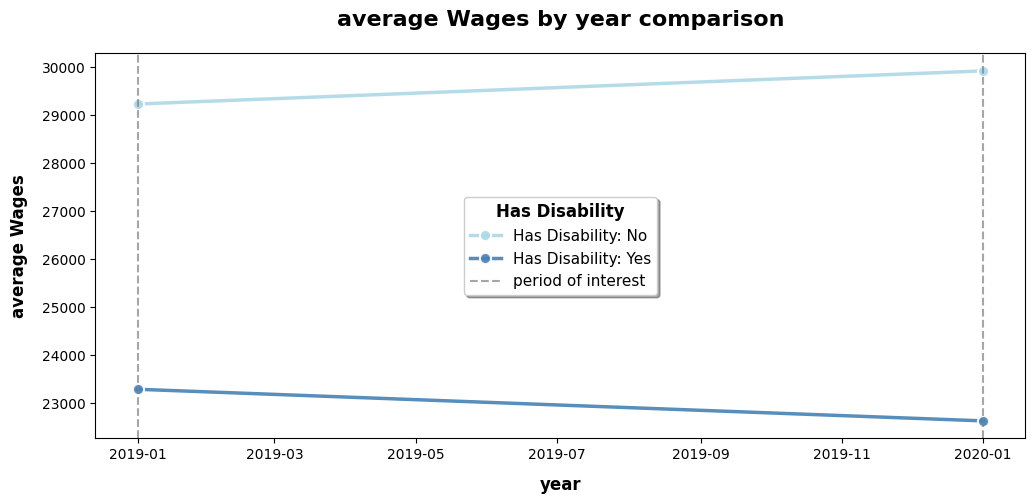

In [176]:
colors = {'Yes': 'steelblue', 'No': 'lightblue'}  # Red for Yes, Green for No
fig, ax = plt.subplots(figsize=(12, 5))
# Plot each disability category with custom styling
for column in df_wages.columns:
    ax.plot(df_wages.index, df_wages[column], 
            marker='o', 
            linewidth=2.5,
            markersize=8,
            color=colors.get(column, '#3498db'),
            label=f'Has Disability: {column}',
            markeredgecolor='white',
            markeredgewidth=1.5,
            alpha=0.9)

# Customize the plot with premium styling
ax.set_title(f'average Wages by year comparison', 
             fontsize=16, 
             fontweight='bold', 
             pad=20,
             #fontfamily='serif'
            )
ax.axvline(x=pd.Timestamp('2019-01-01'), 
           color='gray', 
           linestyle='--', 
           linewidth=1.5, 
           label='period of interest',
           alpha=0.7)  # Optional label

ax.axvline(x=pd.Timestamp('2020-01-01'), 
           color='gray', 
           linestyle='--', 
           linewidth=1.5, 
           alpha=0.7)
ax.set_xlabel('year', fontsize=12, fontweight='semibold', labelpad=10)
ax.set_ylabel(f'average Wages', fontsize=12, fontweight='semibold', labelpad=10)

legend = ax.legend(title='Has Disability',
                  title_fontsize=12,
                  fontsize=11,
                  loc='best',
                  frameon=True,
                  fancybox=True,
                  shadow=True,
                  edgecolor='#cccccc',
                  facecolor='white')
legend.get_title().set_fontweight('bold')

#plt.savefig('../notebooks/agerage_wages_comparison.png')

In [177]:
panel_2019_2020 = panel.copy()
panel_2019_2020['year'] = pd.to_datetime(panel_2019_2020['year'], format='%Y')
panel_2019_2020_ids = panel_2019_2020['idind']
panel_2019_2020 = panel_2019_2020.set_index(['idind', 'year'])
panel_2019_2020

recieves_pension  recieves_pension_30days  amount_pension  \
idind   year                                                                    
60.0    2019-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   
125.0   2019-01-01                 1                        1         15000.0   
        2020-01-01                 1                        1         16000.0   
126.0   2019-01-01                 0                        0             0.0   
...                              ...                      ...             ...   
59275.0 2020-01-01                 0                        0             0.0   
59277.0 2019-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   
59285.0 2019-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   

                    iea_income  total_income  amount_unemp_benefits   wage_j1  \
idind   year                                                                    
60.0    2019-01-01         0.0       18000.0                    0.0   18000.0   
        2020-01-01         0.0       30000.0                    0.0   30000.0   
125.0   2019-01-01         0.0       35000.0                    0.0   20000.0   
        2020-01-01         0.0       45500.0                    0.0   29500.0   
126.0   2019-01-01         0.0       20000.0                    0.0   20000.0   
...                        ...           ...                    ...       ...   
59275.0 2020-01-01         0.0       27000.0                    0.0   27000.0   
59277.0 2019-01-01         0.0       40000.0                    0.0   40000.0   
        2020-01-01         0.0       40000.0                    0.0   40000.0   
59285.0 2019-01-01         0.0      130000.0                    0.0  130000.0   
        2020-01-01         0.0      135000.0                    0.0  135000.0   

                    wage_j2  income_decrease_bc_covid  \
idind   year                                            
60.0    2019-01-01      0.0                         0   
        2020-01-01      0.0                         0   
125.0   2019-01-01      0.0                         0   
        2020-01-01      0.0                         0   
126.0   2019-01-01      0.0                         0   
...                     ...                       ...   
59275.0 2020-01-01      0.0                         1   
59277.0 2019-01-01      0.0                         0   
        2020-01-01      0.0                         1   
59285.0 2019-01-01      0.0                         0   
        2020-01-01      0.0                         0   

                                  work_status  ...  is_married  \
idind   year                                   ...               
60.0    2019-01-01  You are currently working  ...           1   
        2020-01-01  You are currently working  ...           1   
125.0   2019-01-01  You are currently working  ...           1   
        2020-01-01  You are currently working  ...           1   
126.0   2019-01-01  You are currently working  ...           1   
...                                       ...  ...         ...   
59275.0 2020-01-01  You are currently working  ...           0   
59277.0 2019-01-01  You are currently working  ...           0   
        2020-01-01  You are currently working  ...           0   
59285.0 2019-01-01  You are currently working  ...           1   
        2020-01-01  You are currently working  ...           1   

                    period_relevance  is_town  is_female  \
idind   year                                               
60.0    2019-01-01                -1        1          1   
        2020-01-01                 0        1          1   
125.0   2019-01-01                -1        0          1   
        202

In [178]:
model = smf.ols('wages ~ I(has_disablity * period)', data=panel_2019_2020).fit(cov_type='cluster', cov_kwds={'groups': panel_2019_2020_ids})
print(model.summary2())

                          Results: Ordinary least squares
Model:                    OLS                   Adj. R-squared:          0.001      
Dependent Variable:       wages                 AIC:                     109467.3977
Date:                     2026-05-07 20:14      BIC:                     109480.3388
No. Observations:         4772                  Log-Likelihood:          -54732.    
Df Model:                 1                     F-statistic:             7.570      
Df Residuals:             4770                  Prob (F-statistic):      0.00598    
R-squared:                0.001                 Scale:                   5.3685e+08 
------------------------------------------------------------------------------------
                            Coef.     Std.Err.    z    P>|z|     [0.025     0.975]  
------------------------------------------------------------------------------------
Intercept                 29501.1442  431.8564 68.3124 0.0000  28654.7213 30347.5671
I(has_d

In [179]:
model1 = PanelOLS.from_formula('wages ~ I(has_disablity * period) + EntityEffects + TimeEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  wages   R-squared:                        0.0001
Estimator:                   PanelOLS   R-squared (Between):             -0.0005
No. Observations:                4772   R-squared (Within):           -2.836e-06
Date:                Thu, May 07 2026   R-squared (Overall):             -0.0005
Time:                        20:14:18   Log-likelihood                -5.068e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.2436
Entities:                        2386   P-value                           0.6216
Avg Obs:                       2.0000   Distribution:                  F(1,2384)
Min Obs:                       2.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             0.1175
                            

In [180]:
model2 = PanelOLS.from_formula('np.log1p(wages) ~ I(has_disablity * period) + EntityEffects + TimeEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model2.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        np.log1p(wages)   R-squared:                     7.869e-06
Estimator:                   PanelOLS   R-squared (Between):             -0.0002
No. Observations:                4772   R-squared (Within):            5.033e-05
Date:                Thu, May 07 2026   R-squared (Overall):             -0.0002
Time:                        20:14:19   Log-likelihood                -1.002e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.0188
Entities:                        2386   P-value                           0.8911
Avg Obs:                       2.0000   Distribution:                  F(1,2384)
Min Obs:                       2.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             0.0046
                            

In [181]:
# -4331.6
model3 = PanelOLS.from_formula('np.sqrt(wages + 1) - 1 ~ has_disability_period + EntityEffects + TimeEffects', drop_absorbed=True, data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model3.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     np.sqrt(wages + 1)   R-squared:                        0.0007
Estimator:                   PanelOLS   R-squared (Between):             -0.1791
No. Observations:                4772   R-squared (Within):              -0.1665
Date:                Thu, May 07 2026   R-squared (Overall):             -0.1785
Time:                        20:14:22   Log-likelihood                -2.391e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.6707
Entities:                        2386   P-value                           0.1963
Avg Obs:                       2.0000   Distribution:                  F(1,2384)
Min Obs:                       2.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             0.4268
                            

In [182]:
model3 = PanelOLS.from_formula('np.sqrt(wages + 1) - 1 ~ I(has_disability*period) + EntityEffects + TimeEffects', drop_absorbed=True, data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model3.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     np.sqrt(wages + 1)   R-squared:                     4.424e-05
Estimator:                   PanelOLS   R-squared (Between):             -0.0004
No. Observations:                4772   R-squared (Within):            4.377e-05
Date:                Thu, May 07 2026   R-squared (Overall):             -0.0003
Time:                        20:14:45   Log-likelihood                -2.391e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.1055
Entities:                        2386   P-value                           0.7454
Avg Obs:                       2.0000   Distribution:                  F(1,2384)
Min Obs:                       2.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             0.0309
                            

In [172]:
30.242**2

914.578564

In [120]:
model3.summary

Dep. Variable:,wages,R-squared:,0.0004
Estimator:,PanelOLS,R-squared (Between):,-0.0808
No. Observations:,9960,R-squared (Within):,-0.0444
Date:,"Wed, May 06 2026",R-squared (Overall):,-0.0697
Time:,18:20:48,Log-likelihood,-1.091e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,2.8166
Entities:,2386,P-value,0.0933
Avg Obs:,4.1744,Distribution:,"F(1,7568)"
Min Obs:,2.0000,,
Max Obs:,6.0000,F-statistic (robust):,4.4411


In [169]:
model4 = PanelOLS.from_formula('wages ~ has_disability_period + EntityEffects + TimeEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model4.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  wages   R-squared:                        0.0005
Estimator:                   PanelOLS   R-squared (Between):             -0.1019
No. Observations:                8606   R-squared (Within):              -0.0943
Date:                Thu, May 07 2026   R-squared (Overall):             -0.0944
Time:                        20:12:12   Log-likelihood                  -9.3e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.1938
Entities:                        2386   P-value                           0.0740
Avg Obs:                       3.6069   Distribution:                  F(1,6215)
Min Obs:                       2.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             3.7790
                            

In [80]:
disabled_group = (
    pl.from_pandas(panel)
    .filter(pl.col('year') == 2020)
    .filter(pl.col('has_disablity') == 1)
    #.with_columns()
)
disabled_group

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class_first_group,disability_class_second_group,disability_class_third_group,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,harmfull_job,inwgt,is_employed,has_disablity,wages,period,educ_level_higher,educ_level_school_or_less,educ_level_university,is_married,period_relevance,is_town,is_female,has_disability_common,male_retiered,female_retiered,is_retired,has_disability_period,has_disability_common_period
f64,f64,i32,i32,f64,f64,f64,f64,f64,f64,i32,str,i32,i32,i32,i32,u8,u8,u8,i32,f64,str,f64,str,str,str,f64,str,str,i32,i32,f64,i32,i32,f64,i32,u8,u8,u8,i64,i64,i64,i32,i32,i32,i32,i32,i32,i32
132.0,2019.0,1,1,12300.0,0.0,47300.0,0.0,35000.0,0.0,0,"""You are currently working""",0,0,0,0,0,0,1,1,1996.0,"""November""",8.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",57.0,"""Institute, University, Academy…","""In a registered marriage""",0,0,0.791657,1,1,35000.0,0,0,0,1,1,-1,0,1,1,0,0,0,1,1
3824.0,2019.0,1,1,10263.0,0.0,50263.0,0.0,40000.0,0.0,0,"""You are currently working""",0,1,0,1,0,0,1,1,2008.0,"""December""",5.0,"""Kalinin Oblast: Rzhev CR""","""town""","""Rzhev City and Rajon: Tverskay…",58.5,"""Institute, University, Academy…","""In a registered marriage""",0,0,0.950363,1,1,40000.0,0,0,0,1,1,-1,1,1,1,0,0,0,1,1
4262.0,2019.0,1,1,6851.0,0.0,8451.0,0.0,0.0,100.0,0,"""You are currently working""",0,1,0,1,0,0,1,1,2015.0,"""December""",7.0,"""Tomsk""","""oblastnoy center""","""Tomsk: Tomskaya Oblast""",28.5,"""Technical, medical, musis etc …","""Never married""",1,0,0.0,1,1,100.0,0,0,0,0,0,-1,1,0,1,0,0,0,1,1
11284.0,2019.0,1,1,12511.0,0.0,32111.0,0.0,19600.0,0.0,0,"""You are currently working""",0,0,0,0,0,0,1,1,2016.0,"""November""",18.0,"""Moscow Oblast""","""town""","""Moscovskaya Oblast""",72.0,"""Secondary School Diploma""","""Widower or widow""",0,0,0.75658,1,1,19600.0,0,0,0,0,0,-1,1,1,1,0,1,1,1,1
11578.0,2019.0,1,1,13500.0,0.0,31000.0,0.0,17500.0,0.0,0,"""You are currently working""",0,0,0,0,0,0,1,1,2011.0,"""November""",30.0,"""Perm Territory: Solikamsk City…","""town""","""Solikamsk City and Rajon: Perm…",49.5,"""7-9 grades of school [unfinish…","""Never married""",1,0,1.124243,1,1,17500.0,0,0,0,0,0,-1,1,0,1,0,0,0,1,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
55408.0,2019.0,1,1,21000.0,0.0,21000.0,0.0,0.0,0.0,0,"""You are not working""",0,0,0,0,0,0,1,1,1989.0,"""November""",20.0,"""Moscow City""","""oblastnoy center""","""Moscow City""",33.0,"""10 and more grades of school &…","""In a registered marriage""",1,0,1.186254,0,1,0.0,0,1,0,0,1,-1,1,0,1,0,0,0,1,1
56380.0,2019.0,1,1,6000.0,0.0,20000.0,0.0,14000.0,0.0,0,"""You are currently working""",0,1,0,0,0,0,1,1,1990.0,"""November""",5.0,"""Moscow Oblast""","""town""","""Moscovskaya Oblast""",30.0,"""Institute, University, Academy…","""Living together, not registere…",0,0,0.0,1,1,14000.0,0,0,0,1,1,-1,1,1,1,0,0,0,1,1
56850.0,2019.0,0,0,0.0,0.0,31300.0,0.0,25000.0,0.0,0,"""You are currently working""",0,0,0,0,0,0,1,1,2011.0,"""November""",19.0,"""Saratov Oblast: Volskij Goroso…","""town""","""Volsk City and Rajon: Saratovs…",33.0,"""Technical, medical, musis etc …","""In a registered marriage""",1,0,1.186254,1,1,25000.0,0,0,0,0,1,-1,1,0,1,0,0,0,1,1


In [81]:
disabled_group_pd = disabled_group.sort('wages')['wages'].to_pandas()
disabled_group_pd

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
5          0.0
6          0.0
7          0.0
8        100.0
9       6000.0
10      7000.0
11      8000.0
12     10000.0
13     10000.0
14     11000.0
15     13000.0
16     13000.0
17     13000.0
18     14000.0
19     14000.0
20     16000.0
21     16000.0
22     17500.0
23     19600.0
24     20000.0
25     20000.0
26     20000.0
27     20000.0
28     20000.0
29     20000.0
30     22000.0
31     25000.0
32     25000.0
33     25000.0
34     25000.0
35     25000.0
36     30000.0
37     30000.0
38     30000.0
39     30000.0
40     30000.0
41     35000.0
42     35000.0
43     40000.0
44     40000.0
45     50000.0
46     50000.0
47     50000.0
48     50000.0
49     50000.0
50     58602.0
51     70000.0
52    100000.0
Name: wages, dtype: float64

In [135]:
disabled_group = (
    pl.from_pandas(panel)
    .filter(pl.col('year') == 2019)
    .filter(pl.col('has_disablity') == 1)
    # .with_columns(
    #     pl.when(pl.col('wages') > 40000).then(pl.col('wages') - 30_000).otherwise(pl.col('wages'))
    # )
).to_pandas()[['idind', 'total_income', 'wage_j1', 'wage_j2', 'iea_income', 'wages']]
disabled_group

,idind,total_income,wage_j1,wage_j2,iea_income,wages
0,132.0,47300.0,35000.0,0.0,0.0,35000.0
1,3824.0,50263.0,40000.0,0.0,0.0,40000.0
2,4262.0,8451.0,0.0,100.0,0.0,100.0
3,11284.0,32111.0,19600.0,0.0,0.0,19600.0
4,11578.0,31000.0,17500.0,0.0,0.0,17500.0
5,11658.0,13000.0,0.0,0.0,0.0,0.0
6,12257.0,30000.0,22000.0,0.0,0.0,22000.0
7,13184.0,21087.0,11000.0,0.0,0.0,11000.0
8,14238.0,37000.0,30000.0,0.0,0.0,30000.0
9,18029.0,17000.0,10000.0,0.0,0.0,10000.0


In [134]:
disabled_group = (
    pl.from_pandas(panel)
    .filter(pl.col('year') == 2020)
    .filter(pl.col('has_disablity') == 1)
    .with_columns(
        pl.when(pl.col('wages') > 40000).then(pl.col('wages') - 30_000).otherwise(pl.col('wages'))
    )
).to_pandas()[['idind', 'total_income', 'wage_j1', 'wage_j2', 'iea_income', 'wages']]
disabled_group

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,idind,total_income,wage_j1,wage_j2,iea_income,wages
0,132.0,54000.0,38000.0,0.0,0.0,38000.0
1,3824.0,15661.0,0.0,0.0,0.0,0.0
2,4262.0,18700.0,0.0,0.0,0.0,0.0
3,11284.0,36500.0,22000.0,0.0,0.0,22000.0
4,11578.0,27000.0,18500.0,0.0,0.0,18500.0
5,11658.0,23300.0,10000.0,0.0,0.0,10000.0
6,12257.0,28000.0,20000.0,0.0,0.0,20000.0
7,13184.0,21850.0,10500.0,0.0,0.0,10500.0
8,14238.0,12000.0,0.0,0.0,0.0,0.0
9,18914.0,21600.0,0.0,0.0,0.0,0.0


<Axes: ylabel='wages'>

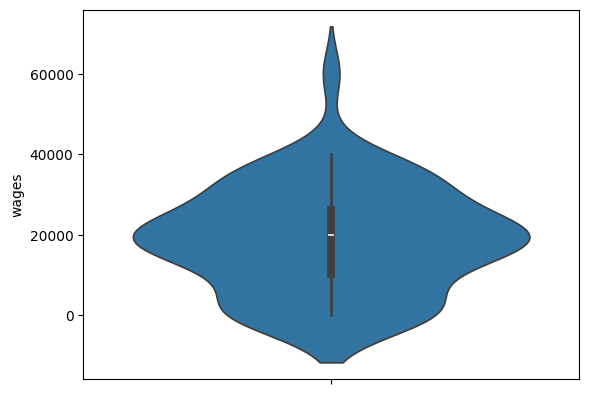

In [74]:
sns.violinplot(disabled_group['wages'])

In [79]:
panel_tmp = pd.concat([
    panel[
        ~(panel['year'] == 2020) & (panel['has_disablity'] == 1)
        ], 
    disabled_group
])
panel_2019_2020 = panel_tmp.copy()
# panel_2019_2020['year'] = pd.to_datetime(panel_2019_2020['year'], format='%Y')
# panel_2019_2020 = panel_2019_2020.set_index(['idind', 'year'])
panel_2019_2020

,idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,...,is_married,period_relevance,is_town,is_female,has_disability_common,male_retiered,female_retiered,is_retired,has_disability_period,has_disability_common_period
29,132.0,2020.0,1,1,16000.0,0.0,54000.0,0.0,38000.0,0.0,...,1,0,0,1,1,0,0,0,2,2
905,3824.0,2020.0,1,1,12931.0,0.0,15661.0,0.0,0.0,0.0,...,1,0,1,1,1,0,0,0,2,2
1032,4262.0,2020.0,1,1,7200.0,0.0,18700.0,11500.0,0.0,0.0,...,0,0,1,0,1,0,0,0,2,2
1811,11284.0,2020.0,1,1,12500.0,0.0,36500.0,0.0,22000.0,0.0,...,0,0,1,1,1,0,1,1,2,2
1852,11578.0,2020.0,0,0,0.0,0.0,27000.0,0.0,18500.0,0.0,...,0,0,1,0,1,0,0,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50,56380.0,2020.0,1,1,6500.0,0.0,11100.0,0.0,4600.0,0.0,...,1,0,1,1,1,0,0,0,2,2
51,56850.0,2020.0,1,1,12000.0,0.0,37000.0,0.0,25000.0,0.0,...,1,0,1,0,1,0,0,0,2,2
52,58293.0,2020.0,1,1,5900.0,0.0,5900.0,0.0,0.0,0.0,...,1,0,1,0,1,0,0,0,2,2
53,58747.0,2020.0,1,1,18550.0,0.0,50550.0,0.0,15000.0,17000.0,...,0,0,1,1,1,0,1,1,2,2


In [76]:
model1 = PanelOLS.from_formula('wages ~ I(has_disablity * period) + EntityEffects + TimeEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  wages   R-squared:                        0.0000
Estimator:                   PanelOLS   R-squared (Between):             -0.0430
No. Observations:                 108   R-squared (Within):               0.0116
Date:                Wed, May 06 2026   R-squared (Overall):             -0.0354
Time:                        17:36:24   Log-likelihood                   -1154.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.0000
Entities:                          59   P-value                           1.0000
Avg Obs:                       1.8305   Distribution:                    F(1,47)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):          2.236e-32
                            